# GraphCast Full — Activation Energy Spectrum & Hydrodynamic Entropy

**GraphCast Full (0.25°, 37 levels, mesh_size=6, M0–M6)**

**No ERA5 data needed** — analysis is purely geometric (W matrix + mesh edges).

| Property | GraphCast Small| GraphCast Operational | GraphCast Full (this) |
|---|---|---|---|
| Resolution | **1.0°** | 0.25° | 0.25° |
| Pressure levels | **13** | 13 | 37 |
| Mesh size (splits) | **5 → M0–M5** | 6 → M0–M6 | 6 → M0–M6 |
| Training data | **ERA5 1979-2015** | ERA5-HRES 1979-2021 | ERA5 1979-2017 |
| Total edges | **81,900** | **3,27,660** |  **3,27,660**  |

In [26]:
# ── CELL 1: Install GraphCast ─────────────────────────────────
%pip install --upgrade https://github.com/deepmind/graphcast/archive/master.zip -q

/usr/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


In [27]:
# ── CELL 2: Imports ───────────────────────────────────────────
import os
import gc
import numpy as np
import xarray as xr
import haiku as hk
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.stats import linregress
from graphcast import graphcast, checkpoint, normalization
from graphcast import data_utils, icosahedral_mesh

print("JAX devices :", jax.devices())
print("GraphCast imported OK")

# Kaggle working directory
WORK_DIR = "/kaggle/working"
os.makedirs(f"{WORK_DIR}/params", exist_ok=True)

JAX devices : [CudaDevice(id=0), CudaDevice(id=1)]
GraphCast imported OK


In [28]:
import subprocess

result = subprocess.run(
    ["gsutil", "ls", "gs://dm_graphcast/graphcast/params/"],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

gs://dm_graphcast/graphcast/params/GraphCast - ERA5 1979-2017 - resolution 0.25 - pressure levels 37 - mesh 2to6 - precipitation input and output.npz
gs://dm_graphcast/graphcast/params/GraphCast_operational - ERA5-HRES 1979-2021 - resolution 0.25 - pressure levels 13 - mesh 2to6 - precipitation output only.npz
gs://dm_graphcast/graphcast/params/GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5 - precipitation input and output.npz




In [29]:
GCS_PATH = "gs://dm_graphcast/graphcast/params/GraphCast - ERA5 1979-2017 - resolution 0.25 - pressure levels 37 - mesh 2to6 - precipitation input and output.npz"

PARAMS_LOCAL = f"{WORK_DIR}/params/graphcast_full.npz"

result = subprocess.run(
    ["gsutil", "cp", GCS_PATH, PARAMS_LOCAL],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)
print("Exit code:", result.returncode)

if result.returncode == 0:
    size = os.path.getsize(PARAMS_LOCAL)
    print(f"Downloaded OK — {size/1e9:.2f} GB")


Copying gs://dm_graphcast/graphcast/params/GraphCast - ERA5 1979-2017 - resolution 0.25 - pressure levels 37 - mesh 2to6 - precipitation input and output.npz...
/ [0 files][    0.0 B/139.2 MiB]                                                
-
- [1 files][139.2 MiB/139.2 MiB]                                                
Operation completed over 1 objects/139.2 MiB.                                    

Exit code: 0
Downloaded OK — 0.15 GB


In [30]:
# ── CELL 4: Load checkpoint ───────────────────────────────────
with open(PARAMS_LOCAL, "rb") as f:
    ckpt = checkpoint.load(f, graphcast.CheckPoint)

params       = ckpt.params
state        = {}
model_config = ckpt.model_config
task_config  = ckpt.task_config

print("mesh_size     :", model_config.mesh_size)   # expect 6
print("latent_size   :", model_config.latent_size)  # expect 512
print("gnn_msg_steps :", model_config.gnn_msg_steps)
print("resolution    :", task_config.input_duration)

mesh_size     : 6
latent_size   : 512
gnn_msg_steps : 16
resolution    : 12h


In [31]:
# ── CELL 5: Inspect encoder weight key ───────────────────────
# Confirm the exact weight key exists in this checkpoint
# (Full model uses the same key as small)

TARGET_KEY = "mesh_gnn/~_networks_builder/encoder_edges_mesh_mlp/~/linear_0"

if TARGET_KEY in params:
    W_shape = np.array(params[TARGET_KEY]["w"]).shape
    b_shape = np.array(params[TARGET_KEY]["b"]).shape
    print(f"Found key  : {TARGET_KEY}")
    print(f"W shape    : {W_shape}   (expect [4, 512])")
    print(f"b shape    : {b_shape}   (expect [512])")
else:
    print("Key NOT found — printing all param keys to help locate it:")
    for k in sorted(params.keys()):
        print(" ", k)

Found key  : mesh_gnn/~_networks_builder/encoder_edges_mesh_mlp/~/linear_0
W shape    : (4, 512)   (expect [4, 512])
b shape    : (512,)   (expect [512])


In [32]:
# ── CELL 6: Build mesh hierarchy + edge level tags ────────────
#
# GraphCast Full uses mesh_size=6  →  levels M0..M6
# M6 is the new finest level at ~156 km  (vs M5=312km in small)

splits = model_config.mesh_size   # 6 for full model
R      = 6371.0                   # Earth radius km

print(f"Building icosahedral mesh hierarchy for splits={splits} ...")
meshes      = icosahedral_mesh.get_hierarchy_of_triangular_meshes_for_sphere(splits=splits)
merged_mesh = icosahedral_mesh.merge_meshes(meshes)
all_senders, all_receivers = icosahedral_mesh.faces_to_edges(merged_mesh.faces)

# Tag each face with its level of origin, then tile by 3 for edges
face_levels = np.concatenate([
    np.full(mesh.faces.shape[0], level, dtype=np.int32)
    for level, mesh in enumerate(meshes)
])
edge_levels = np.tile(face_levels, 3)

print(f"\nTotal edges : {len(edge_levels):,}")
print(f"\n{'Level':<6} {'L_km':>9} {'n_edges':>9}")
print("-" * 28)
for lv in range(splits + 1):
    n    = (edge_levels == lv).sum()
    L_km = np.pi * R / (2 * 2**lv)
    print(f"  M{lv}   {L_km:9.0f} {n:9,}")

Building icosahedral mesh hierarchy for splits=6 ...

Total edges : 327,660

Level       L_km   n_edges
----------------------------
  M0       10008        60
  M1        5004       240
  M2        2502       960
  M3        1251     3,840
  M4         625    15,360
  M5         313    61,440
  M6         156   245,760


In [33]:
# ── CELL 7: Verify face/edge shapes (sanity check) ───────────
print("face_levels shape :", face_levels.shape)
print("edge_levels shape :", edge_levels.shape)
print()
for level, mesh in enumerate(meshes):
    print(f"M{level} faces shape : {mesh.faces.shape}")

face_levels shape : (109220,)
edge_levels shape : (327660,)

M0 faces shape : (20, 3)
M1 faces shape : (80, 3)
M2 faces shape : (320, 3)
M3 faces shape : (1280, 3)
M4 faces shape : (5120, 3)
M5 faces shape : (20480, 3)
M6 faces shape : (81920, 3)


In [ ]:
# ── CELL 8: W·x Hydrodynamic Entropy ─────────────────────────
#
# E(k) = mean ||W·x||² per edge at each mesh level
# Removes edge-count bias — gives true per-mode geometric energy density
#
# W : [4, 512]  encoder weight (shared across ALL levels — single matrix)
# x : [n_edges, 4]  geometric features — level-specific
# W·x : [n_edges, 512]  level-specific linear projection

W = np.array(params[TARGET_KEY]["w"])   # [4, 512]
b = np.array(params[TARGET_KEY]["b"])   # [512]

sender_pos   = merged_mesh.vertices[all_senders]                             
receiver_pos = merged_mesh.vertices[all_receivers]                           
diff         = receiver_pos - sender_pos                                     
length       = np.linalg.norm(diff, axis=-1, keepdims=True)                  
geom         = np.concatenate([diff, length], axis=-1).astype(np.float32)   

print(f"geom shape : {geom.shape}")
print(f"W    shape : {W.shape}")
print("Projecting geom @ W + b  ...")

projected = geom @ W + b   # [N_edges, 512]
print(f"projected shape : {projected.shape}")

# Free geom — no longer needed
del geom, diff, length, sender_pos, receiver_pos
gc.collect()

# ── Per-level mean energy E(k) ────────────────────────────────
E_k     = np.zeros(splits + 1)
n_edges = np.zeros(splits + 1, dtype=int)

for level in range(splits + 1):
    mask           = (edge_levels == level)
    n_edges[level] = mask.sum()
    E_k[level]     = float(np.mean(np.sum(projected[mask]**2, axis=-1)))

# Free projected after extracting E_k
del projected
gc.collect()

L_km_arr = np.array([np.pi * R / (2 * 2**m) for m in range(splits + 1)])
k_arr    = 1.0 / L_km_arr

print(f"\n{'Level':<6} {'L_km':>8} {'n_edges':>9} {'mean||W·x||²  E(k)':>22}")
print("-" * 54)
for m in range(splits + 1):
    print(f"M{m}    {L_km_arr[m]:8.0f} {n_edges[m]:9,} {E_k[m]:22.4e}")

# ── Probabilities + Shannon entropy ──────────────────────────
E_total = E_k.sum()
p_k     = E_k / E_total
S_H     = -np.sum(p_k * np.log2(p_k + 1e-12))
S_max   = np.log2(splits + 1)   # log2(7) for Full model

print(f"\n{'Level':<6} {'p_k':>10} {'-p log2 p':>12}")
print("-" * 32)
for m in range(splits + 1):
    contrib = -p_k[m] * np.log2(p_k[m] + 1e-12)
    print(f"M{m}    {p_k[m]:10.6f} {contrib:12.6f}")

print(f"\nS_H       = {S_H:.4f} ")
print(f"S_max     = {S_max:.4f}  [= log2({splits+1})]")
print(f"S_H/S_max = {S_H/S_max:.4f}  ({100*S_H/S_max:.1f}%)")
print(f"Dominant  : M{np.argmax(p_k)} ({100*p_k.max():.1f}% of total energy)")

# ── Power law fit ─────────────────────────────────────────────
slope, intercept, r_value, *_ = linregress(np.log10(k_arr), np.log10(E_k))
C        = 10**intercept
k_ref    = np.geomspace(k_arr.min(), k_arr.max(), 200)
fit_line = C * k_ref**slope
kolmo    = E_k[0] * (k_ref / k_arr[0])**(-5/3)

print(f"\nPower law  : E(k) = {C:.4e} · k^{slope:.4f}")
print(f"R²         = {r_value**2:.4f}")
print(f"Kolmogorov reference = k^{-5/3:.4f}")

geom shape : (327660, 4)
W    shape : (4, 512)
Projecting geom @ W + b  ...
projected shape : (327660, 512)

Level      L_km   n_edges     mean||W·x||²  E(k)
------------------------------------------------------
M0       10008        60             4.3218e+00
M1        5004       240             1.3311e+00
M2        2502       960             3.5263e-01
M3        1251     3,840             9.0182e-02
M4         625    15,360             2.3395e-02
M5         313    61,440             6.6260e-03
M6         156   245,760             2.4304e-03

Level         p_k    -p log2 p
--------------------------------
M0      0.705239     0.355311
M1      0.217207     0.478476
M2      0.057543     0.237032
M3      0.014716     0.089568
M4      0.003818     0.030667
M5      0.001081     0.010654
M6      0.000397     0.004482

S_H       = 1.2062 
S_max     = 2.8074  [= log2(7)]
S_H/S_max = 0.4297  (43.0%)
Dominant  : M0 (70.5% of total energy)

Power law  : E(k) = 1.8570e-07 · k^-1.8430
R²         =

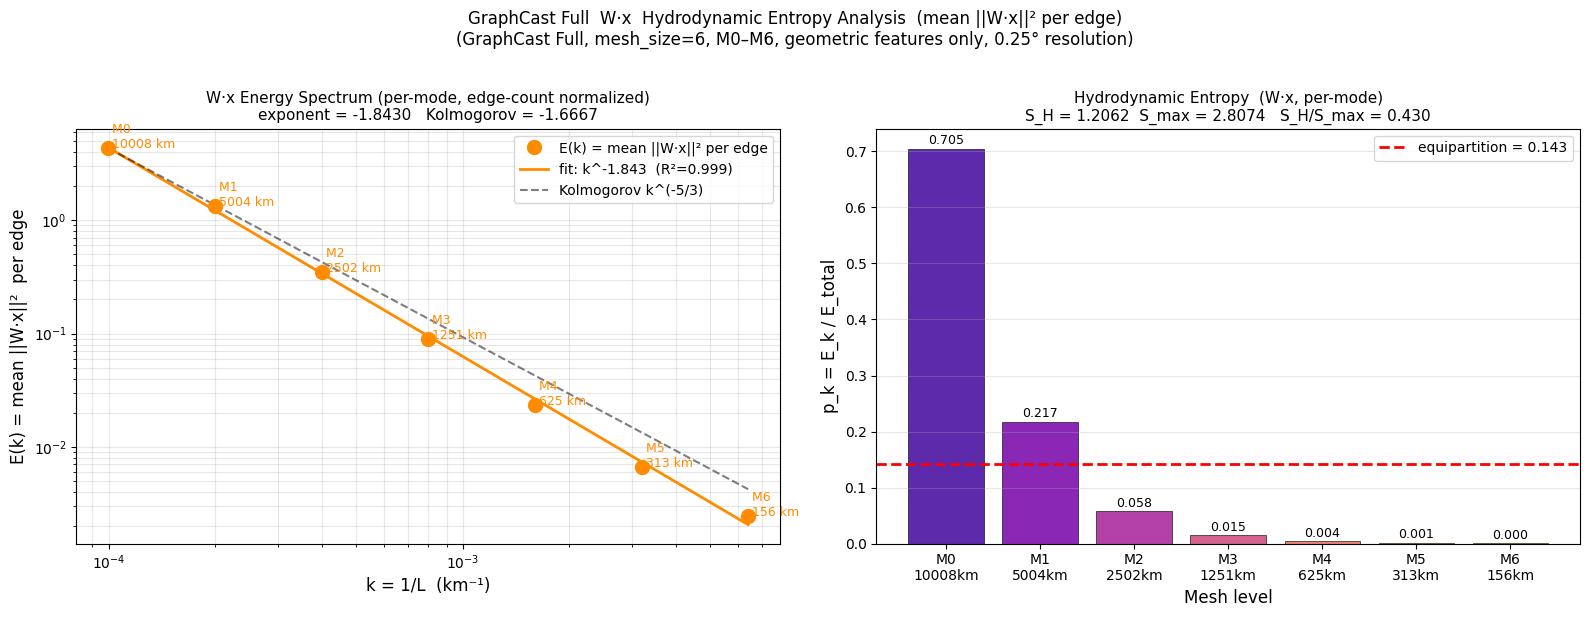

Saved to /kaggle/working/graphcast_full_Wx_mean_entropy.png


In [35]:
# ── CELL 9: Plot — spectrum (left) + bar chart (right) ────────

colors = plt.cm.plasma(np.linspace(0.1, 0.9, splits + 1))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: log-log energy spectrum ────────────────────────────
ax = axes[0]
ax.loglog(k_arr, E_k, 'o', color='darkorange', ms=10, zorder=5,
          label='E(k) = mean ||W·x||² per edge')
ax.loglog(k_ref, fit_line, '-', color='darkorange', lw=2,
          label=f'fit: k^{slope:.3f}  (R²={r_value**2:.3f})')
ax.loglog(k_ref, kolmo, 'k--', alpha=0.5, label='Kolmogorov k^(-5/3)')
for m in range(splits + 1):
    ax.annotate(f' M{m}\n {L_km_arr[m]:.0f} km',
                xy=(k_arr[m], E_k[m]), fontsize=9, color='darkorange')
ax.set_xlabel("k = 1/L  (km⁻¹)", fontsize=12)
ax.set_ylabel("E(k) = mean ||W·x||²  per edge", fontsize=12)
ax.set_title(
    f"W·x Energy Spectrum (per-mode, edge-count normalized)\n"
    f"exponent = {slope:.4f}   Kolmogorov = {-5/3:.4f}",
    fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)

# ── Right: probability bar chart ─────────────────────────────
ax = axes[1]
bars = ax.bar(
    [f'M{m}\n{L_km_arr[m]:.0f}km' for m in range(splits + 1)],
    p_k, color=colors, alpha=0.85, edgecolor='k', lw=0.5
)
ax.axhline(1/(splits+1), color='red', lw=2, linestyle='--',
           label=f'equipartition = {1/(splits+1):.3f}')
for m, bar in enumerate(bars):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{p_k[m]:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel("Mesh level", fontsize=12)
ax.set_ylabel("p_k = E_k / E_total", fontsize=12)
ax.set_title(
    f"Hydrodynamic Entropy  (W·x, per-mode)\n"
    f"S_H = {S_H:.4f}  "
    f"S_max = {S_max:.4f}   "
    f"S_H/S_max = {S_H/S_max:.3f}",
    fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)

plt.suptitle(
    "GraphCast Full  W·x  Hydrodynamic Entropy Analysis  (mean ||W·x||² per edge)\n"
    "(GraphCast Full, mesh_size=6, M0–M6, geometric features only, 0.25° resolution)",
    fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f"{WORK_DIR}/graphcast_full_Wx_mean_entropy.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {WORK_DIR}/graphcast_full_Wx_mean_entropy.png")

In [36]:
# ── CELL 10: Summary ──────────────────────────────────────────
print(f"{'='*55}")
print(f"SUMMARY  —  GraphCast Full  W·x  (mean per edge)")
print(f"{'='*55}")
print(f"Model            : GraphCast Full  (mesh_size={splits})")
print(f"Resolution       : 0.25°,  37 pressure levels")
print(f"Mesh levels      : M0 – M6  ({splits+1} levels)")
print(f"Total edges      : {len(edge_levels):,}")
print()
print(f"S_H              : {S_H:.4f}")
print(f"S_max = log2({splits+1})  : {S_max:.4f}")
print(f"S_H / S_max      : {S_H/S_max:.4f}  ({100*S_H/S_max:.1f}%)")
print(f"Power law exp    : {slope:.4f}  (Kolmogorov = {-5/3:.4f})")
print(f"R²               : {r_value**2:.4f}")
print(f"Dominant level   : M{np.argmax(p_k)} ({100*p_k.max():.1f}% of energy)")
print()
print(f"{'Level':<6} {'L_km':>9} {'n_edges':>9} {'p_k':>10} {'E_k':>14}")
print("-" * 52)
for m in range(splits + 1):
    print(f"M{m}    {L_km_arr[m]:9.0f} {n_edges[m]:9,} {p_k[m]:10.6f} {E_k[m]:14.4e}")

SUMMARY  —  GraphCast Full  W·x  (mean per edge)
Model            : GraphCast Full  (mesh_size=6)
Resolution       : 0.25°,  37 pressure levels
Mesh levels      : M0 – M6  (7 levels)
Total edges      : 327,660

S_H              : 1.2062
S_max = log2(7)  : 2.8074
S_H / S_max      : 0.4297  (43.0%)
Power law exp    : -1.8430  (Kolmogorov = -1.6667)
R²               : 0.9986
Dominant level   : M0 (70.5% of energy)

Level       L_km   n_edges        p_k            E_k
----------------------------------------------------
M0        10008        60   0.705239     4.3218e+00
M1         5004       240   0.217207     1.3311e+00
M2         2502       960   0.057543     3.5263e-01
M3         1251     3,840   0.014716     9.0182e-02
M4          625    15,360   0.003818     2.3395e-02
M5          313    61,440   0.001081     6.6260e-03
M6          156   245,760   0.000397     2.4304e-03
